In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive

'Adventure park '
'AI papers.gsheet'
 chest-xray-pneumonia.zip
'Colab Notebooks'
'Photo link '
'Ramoji Film city'
 refined_dataset
'Research papers.gdoc'
'Resume .pdf'
 RRC_23BDS1054_SriSoumya.docx
"Soumya'25"
'Test Preparation Documents - to be shared with test takers.zip'


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/chest-xray-pneumonia.zip"  # change if inside folder
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


Dataset extracted successfully!


In [4]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)

    if img is None:
        print("Error loading:", img_path)
        return None

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize
    resized = cv2.resize(gray, (224, 224))

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(resized)

    # Normalize
    normalized = enhanced / 255.0

    return normalized

In [6]:
import os
import cv2
import numpy as np

data_path = "/content/data/chest-xray-pneumonia/chest_xray"
save_path = "/content/processed_data"

for split in ["train", "val", "test"]:
    for category in ["NORMAL", "PNEUMONIA"]:

        input_folder = os.path.join(data_path, split, category)
        output_folder = os.path.join(save_path, split, category)

        os.makedirs(output_folder, exist_ok=True)

        for file in os.listdir(input_folder):
            img_path = os.path.join(input_folder, file)
            img = cv2.imread(img_path)

            if img is None:
                continue

            # Convert to grayscale
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Resize
            resized = cv2.resize(gray, (224, 224))

            # CLAHE
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            enhanced = clahe.apply(resized)

            save_file_path = os.path.join(output_folder, file)
            cv2.imwrite(save_file_path, enhanced)

print("All processed images saved successfully!")

All processed images saved successfully!


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [8]:
train_dir = "/content/processed_data/train"
val_dir = "/content/processed_data/val"
test_dir = "/content/processed_data/test"

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary"
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [9]:
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,1)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.3))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.4))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()
model.build

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

<function keras.src.models.sequential.Sequential.build(input_shape=None)>

In [10]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.7525 - loss: 0.5892 - val_accuracy: 0.7500 - val_loss: 0.4821
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9293 - loss: 0.1816 - val_accuracy: 0.8750 - val_loss: 0.4813
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9435 - loss: 0.1415 - val_accuracy: 0.8125 - val_loss: 0.4644
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9602 - loss: 0.1171 - val_accuracy: 0.9375 - val_loss: 0.2892
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9669 - loss: 0.0928 - val_accuracy: 0.6250 - val_loss: 0.8575
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.9684 - loss: 0.0895 - val_accuracy: 0.9375 - val_loss: 0.2886
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9747 - loss: 0.0800 - val_accuracy: 0.8750 - val_loss: 0.2784
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9706 - loss: 0.0806 - val_accuracy: 0.9

In [11]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4854 - loss: 3.2151
Test Accuracy: 0.7179487347602844


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(test_generator)
y_pred = np.round(y_pred)

print(confusion_matrix(test_generator.classes, y_pred))
print(classification_report(test_generator.classes, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
[[ 62 172]
 [  4 386]]
              precision    recall  f1-score   support

           0       0.94      0.26      0.41       234
           1       0.69      0.99      0.81       390

    accuracy                           0.72       624
   macro avg       0.82      0.63      0.61       624
weighted avg       0.78      0.72      0.66       624



In [27]:
from skimage.feature import local_binary_pattern
import matplotlib.pyplot as plt
import cv2
import numpy as np

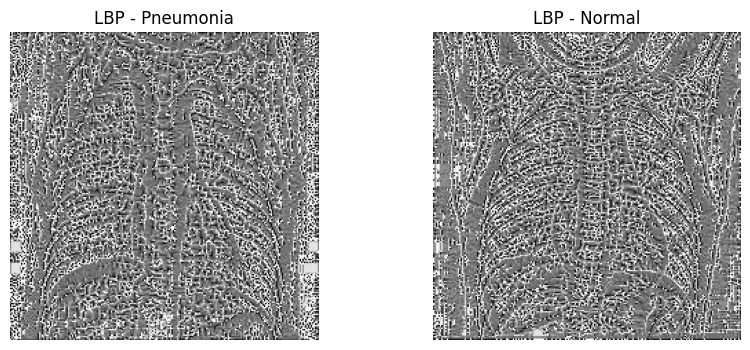

In [29]:
# Load one pneumonia and one normal image
pneumonia_path = "/content/processed_data/train/PNEUMONIA/person1005_virus_1688.jpeg"
normal_path = "/content/processed_data/train/NORMAL/IM-0115-0001.jpeg"

img_p = cv2.imread(pneumonia_path)
img_n = cv2.imread(normal_path)

img_p = cv2.resize(img_p, (224,224))
img_n = cv2.resize(img_n, (224,224))

gray_p = cv2.cvtColor(img_p, cv2.COLOR_BGR2GRAY)
gray_n = cv2.cvtColor(img_n, cv2.COLOR_BGR2GRAY)

# LBP parameters
radius = 1
n_points = 8 * radius

lbp_p = local_binary_pattern(gray_p, n_points, radius, method="uniform")
lbp_n = local_binary_pattern(gray_n, n_points, radius, method="uniform")

# Display
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(lbp_p, cmap='gray')
plt.title("LBP - Pneumonia")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lbp_n, cmap='gray')
plt.title("LBP - Normal")
plt.axis("off")

plt.show()

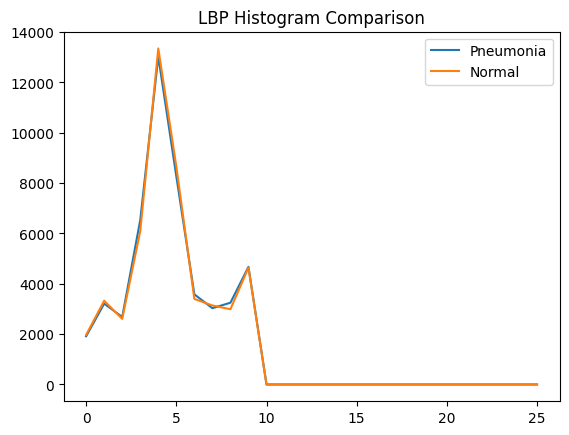

In [30]:
# Histogram comparison
hist_p, _ = np.histogram(lbp_p.ravel(), bins=26, range=(0,26))
hist_n, _ = np.histogram(lbp_n.ravel(), bins=26, range=(0,26))

plt.plot(hist_p, label="Pneumonia")
plt.plot(hist_n, label="Normal")
plt.legend()
plt.title("LBP Histogram Comparison")
plt.show()

In [32]:
radius = 1
n_points = 8 * radius
n_bins = n_points + 2   # for uniform LBP

In [33]:
def extract_lbp_from_folder(folder_path):

    histograms = []

    for file in os.listdir(folder_path):

        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (224, 224))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        lbp = local_binary_pattern(gray, n_points, radius, method="uniform")

        hist, _ = np.histogram(lbp.ravel(),
                               bins=n_bins,
                               range=(0, n_bins))

        # Normalize histogram
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)

        histograms.append(hist)

    # Return mean histogram of entire class
    return np.mean(histograms, axis=0)

In [13]:
normal_path = "/content/processed_data/train/NORMAL"
pneumonia_path = "/content/processed_data/train/PNEUMONIA"

In [35]:
normal_hist = extract_lbp_from_folder(normal_path)
pneumonia_hist = extract_lbp_from_folder(pneumonia_path)

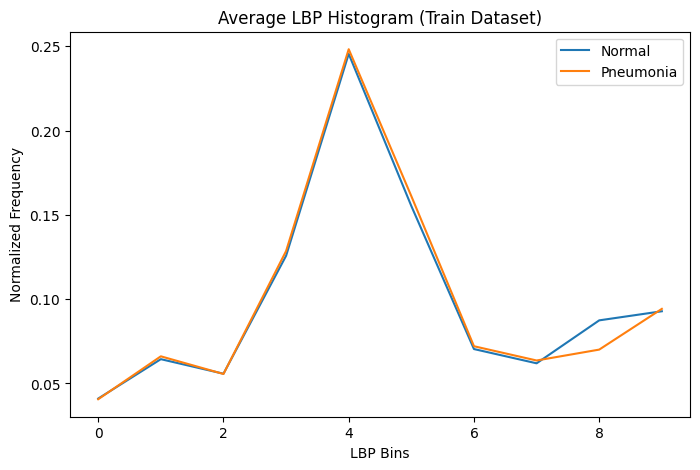

In [36]:
plt.figure(figsize=(8,5))

plt.plot(normal_hist, label="Normal")
plt.plot(pneumonia_hist, label="Pneumonia")

plt.xlabel("LBP Bins")
plt.ylabel("Normalized Frequency")
plt.title("Average LBP Histogram (Train Dataset)")
plt.legend()
plt.show()

In [14]:
from tensorflow.keras.models import Model

layer_outputs = [layer.output for layer in model.layers if "conv" in layer.name]

feature_model = Model(inputs=model.inputs,
                      outputs=layer_outputs)

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/processed_data/train/PNEUMONIA/person1000_bacteria_2931.jpeg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (224,224))
img = img / 255.0

img = np.expand_dims(img, axis=-1)   # add channel dimension
img = np.expand_dims(img, axis=0)    # add batch dimension

In [16]:
feature_maps = feature_model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step


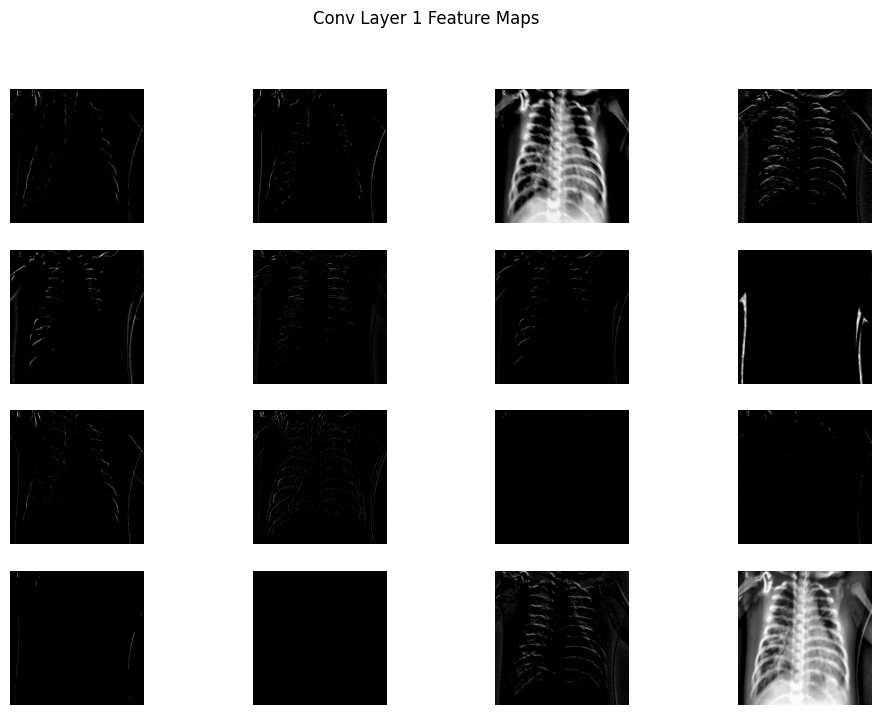

In [17]:
plt.figure(figsize=(12,8))

for i in range(16):  # show first 16 filters
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[0][0, :, :, i], cmap='gray')
    plt.axis('off')

plt.suptitle("Conv Layer 1 Feature Maps")
plt.show()

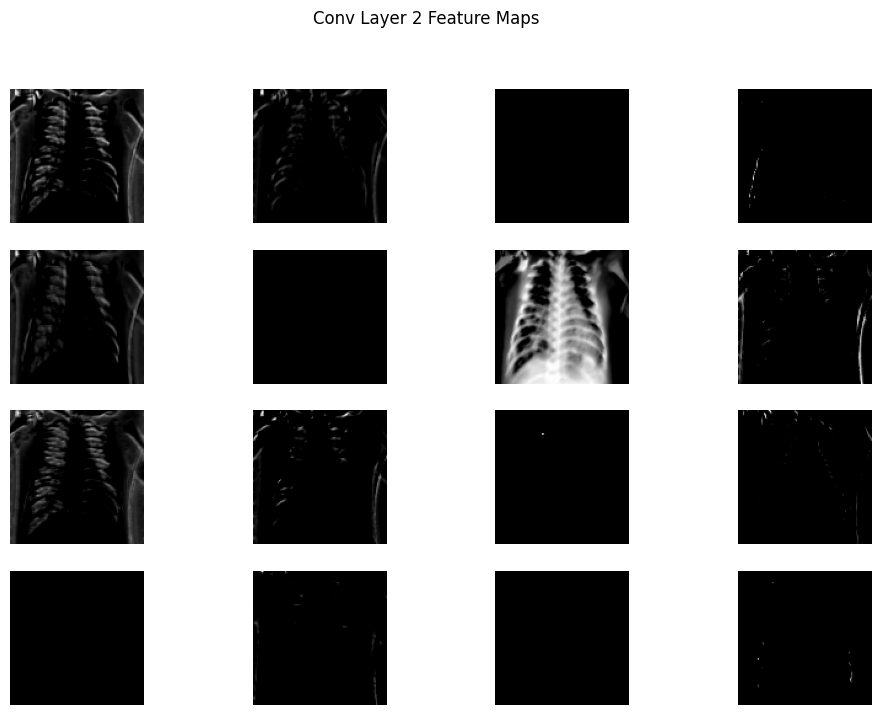

In [18]:
plt.figure(figsize=(12,8))

for i in range(16):  # show first 16 filters
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[1][0, :, :, i], cmap='gray')
    plt.axis('off')

plt.suptitle("Conv Layer 2 Feature Maps")
plt.show()

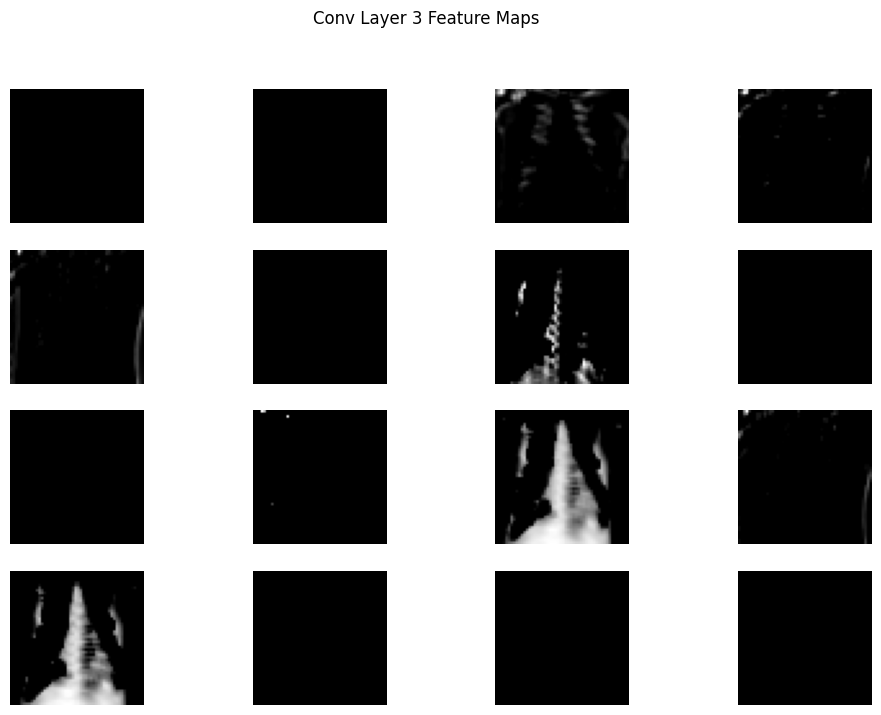

In [19]:
plt.figure(figsize=(12,8))

for i in range(16):  # show first 16 filters
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[2][0, :, :, i], cmap='gray')
    plt.axis('off')

plt.suptitle("Conv Layer 3 Feature Maps")
plt.show()

**RESNET**


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "/content/processed_data/train",
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="binary"
)

val_generator = val_datagen.flow_from_directory(
    "/content/processed_data/val",
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="binary"
)

test_generator = test_datagen.flow_from_directory(
    "/content/processed_data/train",
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 5216 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # Freeze pretrained layers

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 426ms/step - accuracy: 0.7356 - loss: 0.5911 - val_accuracy: 0.5000 - val_loss: 0.9141
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 387ms/step - accuracy: 0.7363 - loss: 0.5177 - val_accuracy: 0.5000 - val_loss: 0.8396
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 398ms/step - accuracy: 0.7460 - loss: 0.4974 - val_accuracy: 0.5000 - val_loss: 0.9762
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 396ms/step - accuracy: 0.7555 - loss: 0.4635 - val_accuracy: 0.5000 - val_loss: 1.1510
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 395ms/step - accuracy: 0.7587 - loss: 0.4580 - val_accuracy: 0.5000 - val_loss: 1.2327
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 396ms/step - accuracy: 0.7743 - loss: 0.4386 - val_accuracy: 0.6250 - val_loss: 0.9678
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 393ms/step - accuracy: 0.7850 - loss: 0.4268 - val_accuracy: 0.5000 - val_loss: 1.1271
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 388ms/step - accuracy: 0.7858 - loss: 0